## Notebooks to investigate only elements open in neuronal context and check the enrichment
1. Approach subset of element which are open
- only subset of elements which are active
- sorted by h1 predictions

2. Look at the distribution of predicted reference effect of elements within the h1 region set
- make cutoff e.g. take the average/median activity of these 
- Check the enrichment of these 

In [52]:
import pandas as pd
import numpy as np
from ast import literal_eval
import os
import yaml
import re


# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# # reload helpful_functions
# from importlib import reload
# reload(hf)

# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

### Create Region (chr;start;end;strand) to Region identifier bed file for all SCREEN regions in the design
- Number of different region identifier found in the input of the MPRAdesign workflow: 30740
1. Read design file 
2. filter for tested sequences by label 
3. regex search for region identifier
4. count unique region identifiers (sanity check) => if 30740 then proceed: 
5. Generate region_id bed file 30740 rows of regions
6. use bedtools and AI to find the easiest way to find overlapping regions

In [33]:
def get_region_info(header):
    """
    cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G => EH38E2358394
    """
    pattern = r"EH38E[\d]+" # EH38E2358394
    region_match = re.search(pattern, header)
    if region_match:
        return region_match.group()
    else:
        print('Header does not contain region info:', header)
        return 'no_match'

In [34]:
design_fasta_df = hf.fasta_to_dataframe(config['files']['final_design']['design_fasta'])
design_fasta_df['tmp_label'] = design_fasta_df['header'].apply(hf.get_label)
tested_design = design_fasta_df.loc[design_fasta_df['tmp_label'] == 'cardiac_neuro_cava_random']
print(tested_design.shape) # (73940, 3)
tested_design.head() # 73940

(73940, 3)


,header,sequence,tmp_label
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTAAGAATACAAGTAACTGATGAATGAAGGGGG...,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTTTGGGTATGCTGCCCCCCAGCTGGCGGGGCA...,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTACGAGCAAGGGAATGAGAGAGAGTGGGTTAG...,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTCGTGGACACGCGTGATTGACCCTTTAACTGT...,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGACCGGATCAACTCCGGAGAGTCTCAGCTCCCGCAGCCCTAACA...,cardiac_neuro_cava_random


In [35]:
# get region information with function
tested_design['region_id'] = tested_design['header'].apply(get_region_info)
tested_design['region_id'].nunique() # 27283

/tmp/ipykernel_184568/4065623321.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_design['region_id'] = tested_design['header'].apply(get_region_info)


27283

In [36]:
# load tested element region file: IGVF_Y1_design/design/final_design/input/regions_5K.bed
element_region_bed = pd.read_csv(config['files']['final_design']['test_seqs_region_file'], sep="\t", header=None)
element_region_bed.columns = ['chr', 'start', 'end', 'header', 'score', 'strand']
element_region_bed.head()
element_region_bed['region_id'] = element_region_bed['header'].apply(get_region_info)
element_region_bed['region_id'].nunique() # 30740

# add length column
element_region_bed['length'] = element_region_bed['end'] - element_region_bed['start']

# check if all regions with same name have same length
region_length = element_region_bed.groupby('region_id')[['chr', 'start', 'end']].nunique()['chr'].sum() # 30740
region_length = element_region_bed.groupby('region_id')[['chr', 'start', 'end']].nunique()['start'].sum() # 30740
region_length = element_region_bed.groupby('region_id')[['chr', 'start', 'end']].nunique()['end'].sum() # 30740
region_length # => same regions same chr start end

# remove duplicated region_ids
element_region_bed = element_region_bed.drop_duplicates(subset=['region_id'])
element_region_bed['region_id'].nunique() # 30740
element_region_bed.shape # (30740, 8)

important_cols = ['chr', 'start', 'end', 'region_id', 'score', 'strand']
element_region_bed = element_region_bed[important_cols]
element_region_bed.columns

Index(['chr', 'start', 'end', 'region_id', 'score', 'strand'], dtype='object')

In [37]:
# #write to file config, creating, unique_tested_elements_region_bed /home/kisa/coding/80K_MPRA/design_data/design_info/unique_tested_element_regions.bed
# element_region_bed.to_csv(config['files']['creating']['unique_tested_elements_region_bed'], sep="\t", header=False, index=False)

In [38]:
tested_design.shape[0]

73940

In [39]:
matched_tested = tested_design.merge(element_region_bed, on='region_id', how='left') # (73940, 9)
matched_tested['start'].isna().sum() # 0 # no missing values
# matched_tested_region_ids = matched_tested['start'].isna() # 0

0

This means we can use the found bed file to overlap the regions given in the narrowPeak file from WTC11 and find regions overlapping

#### Narrow Peak file from Nick page: WTC11 (iPSC derived neurons)
- /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/DIV14_WTC11-NGN2_ExN_ATAC-seq.idr0.05.bfilt.narrowPeak
- make both files bed files
- use bedtools intersect -wa (get region of the tested elements which overlaps somehow the regions of the narrowPeak file)
- Is open: 1.598060

In [40]:
# read narrow peak file in config: files, creating, wtc11_ngn2_atac_narrowPeak
wtc11_ngn2_atac_narrowPeak = pd.read_csv(config['files']['creating']['wtc11_ngn2_atac_narrowPeak'], sep="\t", header=None)
wtc11_ngn2_atac_narrowPeak.columns = ['chr', 'start', 'end', 'name', 'score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak']
wtc11_ngn2_atac_narrowPeak['signalValue'].describe()
# count    37778.000000
# mean         5.519488
# std          2.950569
# min          1.598060
# 25%          3.421990
# 50%          4.747200
# 75%          6.762012
# max         34.925460
wtc11_ngn2_atac_narrowPeak['pValue'].describe() #-log10(pValue) => the higher the more significant
wtc11_ngn2_atac_narrowPeak['qValue'].describe() # min 2.549020 => FDR < 0.01
# get original pValue distribution
# wtc11_ngn2_atac_narrowPeak['original_pvalue'] = 10**-wtc11_ngn2_atac_narrowPeak['pValue']
# histogram of pValue
# import matplotlib.pyplot as plt
# plt.hist(wtc11_ngn2_atac_narrowPeak['pValue'], bins=100)
# plt.hist(wtc11_ngn2_atac_narrowPeak['original_pvalue'], bins=100)
# plt.hist(wtc11_ngn2_atac_narrowPeak['signalValue'], bins=100)
# plt.hist(wtc11_ngn2_atac_narrowPeak['qValue'], bins=100)
# plt.hist(wtc11_ngn2_atac_narrowPeak['peak'], bins=100)


count    37778.000000
mean        47.914968
std         60.585904
min          2.549020
25%         13.903030
50%         26.634130
75%         55.538463
max        894.900760
Name: qValue, dtype: float64

In [41]:
wtc11_ngn2_atac_narrowPeak.columns

Index(['chr', 'start', 'end', 'name', 'score', 'strand', 'signalValue',
       'pValue', 'qValue', 'peak'],
      dtype='object')

##### Using bedtools intersect 
- wb: writes original entry from A and B
- -f 0.5: minimum overlap of 50% of A in B => 0.78% of the found overlaps from -wb are overlapping at least 50% of the region in the narrowPeak file
- wb: `bedtools intersect -wb -a /home/kisa/coding/80K_MPRA/design_data/design_info/unique_tested_element_regions.bed -b /home/kisa/coding/80K_MPRA/WTC11_AT
AC_Ahituv/DIV14_WTC11-NGN2_ExN_ATAC-seq.idr0.05.bfilt.narrowPeak > ngn2_open_NP_and_tested_overlapping_regions.bed`
- -wb + -f 0.5: `bedtools intersect -f 0.5 -wb -a /home/kisa/coding/80K_MPRA/design_data/design_info/unique_tested_element_regions.bed -b /home/kisa/coding/80K_MPRA/W
TC11_ATAC_Ahituv/DIV14_WTC11-NGN2_ExN_ATAC-seq.idr0.05.bfilt.narrowPeak > minoverlap_ngn2_open_NP_and_tested_overlapping_regions.bed`


In [51]:
in_realife_tested_regions = "/home/kisa/coding/80K_MPRA/design_data/design_info/regions.bed"
tested_regions_df = pd.read_csv(in_realife_tested_regions, sep="\t", header=None)
tested_regions_df.columns = ['chr', 'start', 'end', 'header', 'score', 'strand']
tested_regions_df
print(tested_regions_df.shape) # (28390, 6)
tested_regions_df['tmp_label'] = tested_regions_df['header'].apply(hf.get_label)
# only tested regions
tested_regions_df = tested_regions_df.loc[tested_regions_df['tmp_label'] == 'cardiac_neuro_cava_random']
# remove duplicated regions
tested_regions_df = tested_regions_df.drop_duplicates(subset=['chr', 'start', 'end'])
print(tested_regions_df.shape) # (27283, 7)

# drop tmp_label column
tested_regions_df = tested_regions_df.drop(columns=['tmp_label'])

# write to file
tested_regions_df.to_csv(config['files']['creating']['unique_in_realife_regions_bed'], sep="\t", header=False, index=False)

(28390, 6)
(27283, 7)


Using the actually designed sequence regions (focusing on tested sequences and made unique): /home/kisa/coding/80K_MPRA/design_data/design_info/unique_ir_regions.bed
bedtools intersect -wa -a /home/kisa/coding/80K_MPRA/design_data/design_info/unique_ir_regions.bed -b /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/DIV14_WTC11-NGN2_ExN_ATAC-seq.idr0.05.bfilt.narrowPeak > /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/in_reallife_ngn2_open_NP_tested_overlapping_regions.bed

bedtools intersect -wb -a /home/kisa/coding/80K_MPRA/design_data/design_info/unique_ir_regions.bed -b /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/DIV14_WTC11-NGN2_ExN_ATAC-seq.idr0.05.bfilt.narrowPeak > /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/in_reallife_tested_regions_and_ngn2_open_NP_overlapping_regions.bed
=> 368 unique regions overlapping 

Using -f 0.5 (50% overlap): 283 unique regions overlapping => 0.77% of the found overlaps from -wb are overlapping at least 50% of the region in the narrowPeak file

In [62]:
# add this result to the metadata file (see state_of_data.ipynb) (add the columns to the meta data file)

# read file config files, creating, in_realife_wtc11_ngn2_atac_tested_elements_overlap_verbose_annotation
in_realife_ngn2_wtc11_overlap = config['files']['creating']['in_reality_wtc11_ngn2_atac_tested_elements_overlap']
ngn2_wtc11_overlap_df = pd.read_csv(in_realife_ngn2_wtc11_overlap, sep="\t", header=None)
ngn2_wtc11_overlap_df.columns = ['chr', 'start', 'end', 'name', 'score', 'strand']
ngn2_wtc11_overlap_df
# drop duplicated regions
ngn2_wtc11_overlap_df = ngn2_wtc11_overlap_df.drop_duplicates(subset=['name'])


# make new identifier chr_start_end for the regions and add column is_open_wtc11_ngn2_atac_NP
def make_region_identifier(row):
    return f"{row['chr']}_{row['start']}_{row['end']}"

ngn2_wtc11_overlap_df['region_id'] = ngn2_wtc11_overlap_df['name'].apply(hf.get_region_info)
ngn2_wtc11_overlap_df['region_id'].nunique() # 368
ngn2_wtc11_overlap_df
# # sanity check: should be unique
# print(ngn2_wtc11_overlap_df['region_id'].nunique()) # 368
# print(ngn2_wtc11_overlap_df.shape) # 368 => unique new identifier

# make same identifier for the tested elements

# merge the two dataframes on the new identifier

# check if rest is NA

# make same column for H1

# then get the numbers: how many variants, how many ref/alt, how many regions

# Then investigate the length of the regions identified to be open (length distribution of DNAse peaks and ATAC peaks)


368

### Investigate barcode MPRAlm results and merge with H1 neural progenitor cells

In [120]:
# First question: how many elements do I find in the random set 143
merged_bcMPRAlm_snakeflow_info = pd.read_csv(config['files']['creating']['combined_variant_meta_info_local'], sep="\t")
merged_bcMPRAlm_snakeflow_info['chr_pos_ref_alt'] = merged_bcMPRAlm_snakeflow_info['variant_id'].apply(hf.get_chrom_pos_ref_alt_pattern)

merged_bcMPRAlm_snakeflow_info['enformer_variant_info'] = merged_bcMPRAlm_snakeflow_info['enformer_variant_info'].apply(literal_eval)
merged_bcMPRAlm_snakeflow_info['enformer_class_list'] = merged_bcMPRAlm_snakeflow_info['enformer_variant_info'].apply(hf.get_enformer_class_list)
merged_bcMPRAlm_snakeflow_info['gene_set_list'] = merged_bcMPRAlm_snakeflow_info['enformer_variant_info'].apply(hf.get_gene_set_list)
merged_bcMPRAlm_snakeflow_info['variant_type_list'] = merged_bcMPRAlm_snakeflow_info['enformer_variant_info'].apply(hf.get_variant_type_list)

In [90]:
merged_bcMPRAlm_snakeflow_info.to_csv('tmp_table_merged_bcMPRAlm_snakeflow_info.tsv', sep="\t", index=False)

In [121]:
# check if chrom pos ref alt + REF_ID is unique identifier => yes
merged_bcMPRAlm_snakeflow_info[['chr_pos_ref_alt', 'REF_ID']].nunique()
merged_bcMPRAlm_snakeflow_info[['chr_pos_ref_alt', 'REF_ID']].duplicated().sum()
# merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info.duplicated(subset='chr_pos_ref_alt', keep=False)].sort_values(by='chr_pos_ref_alt')
# merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info.duplicated(subset='chr_pos_ref_alt', keep=False)].sort_values(by='chr_pos_ref_alt')['REF_ID'].to_list()

0

In [92]:
merged_bcMPRAlm_snakeflow_info.head()

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max,variant_type,REF_DNASE:neural stem progenitor cell originated from H1-hESC,id,variant_DNASE:neural stem progenitor cell originated from H1-hESC,variant_type_list
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,26.678520,16.150892,343.479770,16.150892,343.479770,singleton,0.2112,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,3.230990,[singleton]
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,3.795257,11.369314,19.146544,11.369314,19.146544,rare,0.1749,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,12.338594,[rare]
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,5.332857,0.763544,39.061070,0.763544,39.061070,singleton,0.3061,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,14.999283,[singleton]
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,21.589469,14.814480,26.345566,14.814480,26.345566,ultra-rare,0.1496,cardiac_neuro_cava_random:ATR|ENSG00000175054....,14.484218,[ultra-rare]
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,1.717218,5.488126,110.387634,5.488126,110.387634,singleton,0.1550,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,4.657819,[singleton]


In [93]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

#### Add prediction information of variant based on h1 and sequence based from h1 (already done)
- look on the distribution of the sequence based predictions of the references

In [122]:
# h1_variant_prediction_path = '/home/kisa/coding/80K_MPRA/enformer_data/baseline_activity/H1_neural_stem_progenitor_enformer_dnase_variant.tsv.gz'
# h1_sequence_prediction_path = '/home/kisa/coding/80K_MPRA/enformer_data/baseline_activity/H1_neural_stem_progenitor_enformer_dnase.tsv.gz'
# h1_variant_prediction_df = pd.read_csv(h1_variant_prediction_path, sep="\t")
# h1_variant_prediction_df.columns = ['id', 'variant_DNASE:neural stem progenitor cell originated from H1-hESC']
# h1_sequence_prediction_df = pd.read_csv(h1_sequence_prediction_path, sep="\t")
# h1_sequence_prediction_df.columns = ['id', 'REF_DNASE:neural stem progenitor cell originated from H1-hESC']
# h1_variant_prediction_df


In [123]:
# h1_sequence_prediction_df

In [102]:
# # merge sequences with REF_ID
# merged_bcMPRAlm_snakeflow_info_h1 = merged_bcMPRAlm_snakeflow_info.merge(h1_sequence_prediction_df, left_on='REF_ID_matchable', right_on='id', how='left')
# # merged_bcMPRAlm_snakeflow_info_h1.drop(columns=['id'], inplace=True)
# # merge variants with chr_pos_ref_alt
# h1_variant_prediction_df['chr_pos_ref_alt'] = h1_variant_prediction_df['id'].apply(hf.get_chrom_pos_ref_alt_pattern)
# merged_bcMPRAlm_snakeflow_info_h1 = merged_bcMPRAlm_snakeflow_info_h1.merge(h1_variant_prediction_df, on='chr_pos_ref_alt', how='left')

# # remove duplicates after matching (REF_ID and chr_pos_ref_alt are possible unique variant_id)
# merged_bcMPRAlm_snakeflow_info_h1_unique = merged_bcMPRAlm_snakeflow_info_h1.drop_duplicates(subset=['chr_pos_ref_alt', 'REF_ID'])

# # Show duplicates:
# # merged_bcMPRAlm_snakeflow_info_h1.loc[merged_bcMPRAlm_snakeflow_info_h1.duplicated(subset='chr_pos_ref_alt', keep=False)].sort_values(by='chr_pos_ref_alt')

Investigate why some variants do not get the annotation of the variant prediction (problem solved wrong variant file used)

In [103]:
# different_var_pos_h1_prediction = set(h1_variant_prediction_df['chr_pos_ref_alt'].to_list())
# different_var_pos_bcMPRAlm_results = set(merged_bcMPRAlm_snakeflow_info['chr_pos_ref_alt'].to_list())

In [105]:
# len(different_var_pos_h1_prediction) # 31599 => 45738
# len(different_var_pos_bcMPRAlm_results) # 36168

45738

In [106]:
# len(different_var_pos_bcMPRAlm_results - different_var_pos_h1_prediction) # => 0

0

Check if it is because of the missing variant ids

In [107]:
# missing_variant_ids = pd.read_csv('/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/notebooks/missing_variant_ids.tsv', sep="\t")
# missing_variant_ids['chr_pos_ref_alt'] = missing_variant_ids['variant_id'].apply(hf.get_chrom_pos_ref_alt_pattern)
# missing_variant_id_set = set(missing_variant_ids['chr_pos_ref_alt'].to_list())
# len(missing_variant_id_set)

854

In [81]:
# len(different_var_pos_bcMPRAlm_results - different_var_pos_h1_prediction - missing_variant_id_set)

10830

In [82]:
# 11684 - 10830

854

In [127]:
merged_bcMPRAlm_snakeflow_info

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max,variant_type,REF_DNASE:neural stem progenitor cell originated from H1-hESC,id,variant_DNASE:neural stem progenitor cell originated from H1-hESC,variant_type_list
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,26.678520,16.150892,343.479770,16.150892,343.479770,singleton,0.2112,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,3.230990,[singleton]
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,3.795257,11.369314,19.146544,11.369314,19.146544,rare,0.1749,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,12.338594,[rare]
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,5.332857,0.763544,39.061070,0.763544,39.061070,singleton,0.3061,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,14.999283,[singleton]
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,21.589469,14.814480,26.345566,14.814480,26.345566,ultra-rare,0.1496,cardiac_neuro_cava_random:ATR|ENSG00000175054....,14.484218,[ultra-rare]
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,1.717218,5.488126,110.387634,5.488126,110.387634,singleton,0.1550,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,4.657819,[singleton]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36176,-0.000170,-0.383716,-0.002306,9.981607e-01,9.993533e-01,-6.829957,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,Region=TMEM70|ENSG00000175606.11|EH38E3840361_...,0.000007,1.0,...,7.204287,-2.571840,13.445777,2.571840,13.445777,singleton,0.1185,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,-5.781922,[singleton]
36177,0.001108,0.266076,0.016283,9.870124e-01,9.966272e-01,-6.829960,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,Region=CHD7|ENSG00000171316.14|EH38E3836279_fw...,0.021523,3273.0,...,0.193621,-2.892175,9.381547,2.892175,9.381547,rare,0.0942,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,-2.955165,[rare]
36178,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,1.591375,5.422453,17.745241,5.422453,17.745241,rare,0.0894,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,-0.944763,[rare]
36179,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,1.591375,5.422453,17.745241,5.422453,17.745241,rare,0.1176,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,-0.944763,[rare]


#### Load open element bed and get 

In [19]:
# screen_h1_DNase_H1_neuro_bed_path = '/home/kisa/coding/80K_MPRA/info/screen_bed/ENCFF287XRW_ENCFF872FDO_ENCFF110SOE.7group.bed' # checked if all regions can be matched if I take the whole file
screen_h1_DNase_H1_neuro_bed_path = '/home/kisa/coding/80K_MPRA/info/screen_bed/non_low_Dnase_H1_neuro.bed'
screen_h1_DNase_H1_neuro_bed = pd.read_csv(screen_h1_DNase_H1_neuro_bed_path, sep="\t", header=None)
# set columns
screen_bed_columns = ['DNase_H1_neuro_chrom', 'DNase_H1_neuro_start', 'DNase_H1_neuro_end', 'DNase_H1_neuro_region', 'DNase_H1_neuro_score', 'DNase_H1_neuro_strand', 'DNase_H1_neuro_thickStart', 'DNase_H1_neuro_thickEnd', 'DNase_H1_neuro_itemRgb', 'DNase_H1_neuro_regionType', 'DNase_H1_neuro_info']
screen_h1_DNase_H1_neuro_bed.columns = screen_bed_columns

In [17]:
screen_h1_DNase_H1_neuro_bed

,chrom,start,end,region,score,strand,thickStart,thickEnd,itemRgb,regionType,info
0,chr1,267925,268171,EH38E2776528,0,.,267925,268171,"6,218,147",DNase-only,Missing-data/Partial-classification
1,chr1,778570,778919,EH38E2776539,0,.,778570,778919,"255,0,0",PLS,Missing-data/Partial-classification
2,chr1,779026,779180,EH38E2776540,0,.,779026,779180,"255,0,0",PLS,Missing-data/Partial-classification
3,chr1,827417,827767,EH38E2776555,0,.,827417,827767,"255,0,0",PLS,Missing-data/Partial-classification
4,chr1,869718,870065,EH38E2776581,0,.,869718,870065,"6,218,147",DNase-only,Missing-data/Partial-classification
...,...,...,...,...,...,...,...,...,...,...,...
135126,chrY,19745112,19745280,EH38E3951073,0,.,19745112,19745280,"255,167,0",pELS,Missing-data/Partial-classification
135127,chrY,20575517,20575867,EH38E2776256,0,.,20575517,20575867,"255,0,0",PLS,Missing-data/Partial-classification
135128,chrY,20575972,20576130,EH38E3951113,0,.,20575972,20576130,"255,167,0",pELS,Missing-data/Partial-classification
135129,chrY,26670948,26671287,EH38E3951269,0,.,26670948,26671287,"6,218,147",DNase-only,Missing-data/Partial-classification


In [24]:
h1_intersting_columns = ['DNase_H1_neuro_chrom', 'DNase_H1_neuro_start', 'DNase_H1_neuro_end', 'DNase_H1_neuro_region']
matched_tested_h1_open = tested_design.merge(screen_h1_DNase_H1_neuro_bed[h1_intersting_columns], left_on='region_id', right_on='DNase_H1_neuro_region', how='left') # (73940, 9)
matched_tested_h1_open.loc[~matched_tested_h1_open['DNase_H1_neuro_start'].isna()].shape[0] # 4653
# length distri atac und dnase seq
# check overlap on actual sequences

4653

Use bedtools intersect for overlap with actually tested regions
- bedtools intersect -wb -a /home/kisa/coding/80K_MPRA/design_data/design_info/unique_ir_regions.bed -b /home/kisa/coding/80K_MPRA/info/screen_bed/non_low_Dnase_H1_neuro.bed > /home/kisa/coding/80K_MPRA/DNase_H1_neural_progenitor_screen/in_reallife_tested_regions_and_h1_neural_dnase_open_screen_overlapping_regions_verbose.bed
- less verbose:
- bedtools intersect -wa -a /home/kisa/coding/80K_MPRA/design_data/design_info/unique_ir_regions.bed -b /home/kisa/coding/80K_MPRA/info/screen_bed/non_low_Dnase_H1_neuro.bed > /home/kisa/coding/80K_MPRA/DNase_H1_neural_progenitor_screen/in_reallife_tested_regions_and_h1_neural_dnase_open_screen_overlapping_regions.bed
- /home/kisa/coding/80K_MPRA/info/screen_bed/non_low_Dnase_H1_neuro.bed

In [23]:
def get_region_info(header):
    """
    cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G => EH38E2358394
    """
    pattern = r"EH38E[\d]+" # EH38E2358394
    region_match = re.search(pattern, header)
    if region_match:
        return region_match.group()
    else:
        print('Header does not contain region info:', header)
        return 'no_match'

In [131]:
merged_bcMPRAlm_snakeflow_info_h1_unique.columns
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

In [168]:
merged_bcMPRAlm_snakeflow_info['region_info'].nunique()

15098

In [132]:
merged_bcMPRAlm_snakeflow_info_h1_unique['region_info'] = merged_bcMPRAlm_snakeflow_info_h1_unique['variant_id'].apply(get_region_info)
merged_bcMPRAlm_snakeflow_info['region_info'] = merged_bcMPRAlm_snakeflow_info['variant_id'].apply(get_region_info)

In [133]:
merged_bcMPRAlm_snakeflow_info_h1_unique.shape[0]
merged_bcMPRAlm_snakeflow_info.shape[0]

36181

In [134]:
# tmp_merged_bcMPRAlm_snakeflow_info_H1 = merged_bcMPRAlm_snakeflow_info_h1_unique.merge(screen_h1_DNase_H1_neuro_bed[['region', 'chrom', 'start', 'end']], left_on='region_info', right_on='region', how='left')
# merged_bcMPRAlm_snakeflow_info_H1_open = tmp_merged_bcMPRAlm_snakeflow_info_H1.loc[~tmp_merged_bcMPRAlm_snakeflow_info_H1['chrom'].isna()]
tmp_merged_bcMPRAlm_snakeflow_info_H1 = merged_bcMPRAlm_snakeflow_info.merge(screen_h1_DNase_H1_neuro_bed[['region', 'chrom', 'start', 'end']], left_on='region_info', right_on='region', how='left')
merged_bcMPRAlm_snakeflow_info_H1_open = tmp_merged_bcMPRAlm_snakeflow_info_H1.loc[~tmp_merged_bcMPRAlm_snakeflow_info_H1['chrom'].isna()]

In [135]:
print(f'Number of open elements in merged_bcMPRAlm_snakeflow_info {merged_bcMPRAlm_snakeflow_info_H1_open.shape[0]}, ratio: {merged_bcMPRAlm_snakeflow_info_H1_open.shape[0]/merged_bcMPRAlm_snakeflow_info.shape[0]}')

Number of open elements in merged_bcMPRAlm_snakeflow_info 1777, ratio: 0.049114175948702356


In [169]:
merged_bcMPRAlm_snakeflow_info_H1_open['region_info'].nunique()

711

In [ ]:
merged_bcMPRAlm_snakeflow_info_H1_open

##### Investigate number of common in signficiant open 

In [167]:
(merged_bcMPRAlm_snakeflow_info_H1_open['adj.P.Val'] < 0.05).sum()

40

In [170]:
significant_open_H1 = merged_bcMPRAlm_snakeflow_info_H1_open.loc[merged_bcMPRAlm_snakeflow_info_H1_open['adj.P.Val'] < 0.05]

significant_open_H1
significant_open_H1_gene_set_exploded = significant_open_H1.explode('gene_set_list').rename(columns={'gene_set_list': 'gene_set'})
significant_open_H1_gene_set_exploded
significant_open_H1_gene_set_exploded['gene_set'].value_counts()

gene_set
cardiac    16
neuro      15
cava        7
random      3
Name: count, dtype: int64

In [171]:
significant_open_H1['variant_type'].value_counts()

variant_type
ultra-rare    17
singleton      9
rare           9
common         5
Name: count, dtype: int64

In [136]:
merged_bcMPRAlm_snakeflow_info_H1_open.gene_set_list.value_counts()
merged_bcMPRAlm_snakeflow_info_H1_open_gene_set_exploded = merged_bcMPRAlm_snakeflow_info_H1_open.explode('gene_set_list').rename(columns={'gene_set_list': 'gene_set'})
merged_bcMPRAlm_snakeflow_info_H1_open_gene_set_exploded['gene_set'].value_counts()

gene_set
cardiac    627
neuro      580
random     319
cava       300
Name: count, dtype: int64

##### Investigate predicted activity distribution 
- most values are pretty small the lower tail is around 0 and 0.25 so taking a prediction of 0.3 is a threshold 

In [137]:
merged_bcMPRAlm_snakeflow_info_h1_unique.columns
merged_bcMPRAlm_snakeflow_info_H1_open.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

In [138]:
merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC']

14       0.1479
23       0.3217
24       0.8480
50       0.3217
63       0.6344
          ...  
35621    0.0917
35707    0.0771
35753    0.1486
35795    0.1237
36131    0.2863
Name: REF_DNASE:neural stem progenitor cell originated from H1-hESC, Length: 1777, dtype: float64

In [139]:
merged_bcMPRAlm_snakeflow_info_H1_open

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,variant_type,REF_DNASE:neural stem progenitor cell originated from H1-hESC,id,variant_DNASE:neural stem progenitor cell originated from H1-hESC,variant_type_list,region_info,region,chrom,start,end
14,1.236787,1.040305,9.642299,9.193902e-20,2.249074e-16,33.614563,cardiac_neuro_cava_random:H1-3|ENSG00000124575...,Region=H1-3|ENSG00000124575.7|EH38E3697725_rev...,0.000007,1.0,...,singleton,0.1479,cardiac_neuro_cava_random:H1-3|ENSG00000124575...,13.489957,[singleton],EH38E3697725,EH38E3697725,chr6,26268978.0,26269314.0
23,-1.583897,0.888105,-8.995560,3.305703e-17,5.776165e-14,27.520431,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,Region=NOS1AP|ENSG00000198929.13|EH38E2844159_...,0.000007,1.0,...,singleton,0.3217,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,-182.056670,[singleton],EH38E2844159,EH38E2844159,chr1,162144844.0,162145191.0
24,1.487462,1.124817,8.984031,4.733339e-17,7.236881e-14,26.943988,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E2610941_f...,0.199174,30227.0,...,common,0.8480,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,-31.936155,[common],EH38E2610941,EH38E2610941,chr8,11642329.0,11642678.0
50,-1.198502,0.986356,-7.402733,1.312239e-12,9.441430e-10,17.846692,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,Region=NOS1AP|ENSG00000198929.13|EH38E2844159_...,0.000046,7.0,...,ultra-rare,0.3217,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,-84.827835,[ultra-rare],EH38E2844159,EH38E2844159,chr1,162144844.0,162145191.0
63,1.090563,0.784401,7.019211,1.454739e-11,8.340654e-09,15.600715,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,Region=LZTR1|ENSG00000099949.22|EH38E3469088_f...,0.000020,3.0,...,ultra-rare,0.6344,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,178.161400,[ultra-rare],EH38E3469088,EH38E3469088,chr22,21014704.0,21015053.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35621,0.028806,-0.013551,0.373009,7.092317e-01,9.528381e-01,-6.747032,cardiac_neuro_cava_random:NBEA|ENSG00000172915...,Region=NBEA|ENSG00000172915.20|EH38E1667522_fw...,0.010438,1588.0,...,rare,0.0917,cardiac_neuro_cava_random:NBEA|ENSG00000172915...,5.149928,[rare],EH38E1667522,EH38E1667522,chr13,35477057.0,35477265.0
35707,-0.014989,0.036330,-0.205526,8.372114e-01,9.760640e-01,-6.758024,cardiac_neuro_cava_random:HAND2|ENSG0000016410...,Region=HAND2|ENSG00000164107.9|EH38E3616136_re...,0.000046,7.0,...,ultra-rare,0.0771,cardiac_neuro_cava_random:HAND2|ENSG0000016410...,12.751076,[ultra-rare],EH38E3616136,EH38E3616136,chr4,173526589.0,173526830.0
35753,0.001847,-0.111496,0.023151,9.815358e-01,9.959129e-01,-6.765079,cardiac_neuro_cava_random:RERE|ENSG00000142599...,Region=RERE|ENSG00000142599.20|EH38E1316082_re...,0.024226,3684.0,...,rare,0.1486,cardiac_neuro_cava_random:RERE|ENSG00000142599...,0.368723,[rare],EH38E1316082,EH38E1316082,chr1,8419962.0,8420218.0
35795,0.009779,-0.028999,0.129976,8.966167e-01,9.864391e-01,-6.772484,cardiac_neuro_cava_random:KANSL1|ENSG000001200...,Region=KANSL1|ENSG00000120071.15|EH38E3227102_...,0.115913,17415.0,...,common,0.1237,cardiac_neuro_cava_random:KANSL1|ENSG000001200...,4.649211,[common],EH38E3227102,EH38E3227102,chr17,46146094.0,46146381.0


In [23]:
merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'].describe()
merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'].quantile(0.95)
# merged_bcMPRAlm_snakeflow_info_H1_open
merged_bcMPRAlm_snakeflow_info_H1_open.loc[merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'] > 0.3]


,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,variant_type,chr_pos_ref_alt,REF_DNASE:neural stem progenitor cell originated from H1-hESC,id,variant_DNASE:neural stem progenitor cell originated from H1-hESC,region_info,region,chrom,start,end
23,-1.583897,0.888105,-8.995560,3.305703e-17,5.776165e-14,27.520431,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,Region=NOS1AP|ENSG00000198929.13|EH38E2844159_...,0.000007,1.0,...,singleton,1-162145083-C-A,0.3217,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,-182.056670,EH38E2844159,EH38E2844159,chr1,162144844.0,162145191.0
24,1.487462,1.124817,8.984031,4.733339e-17,7.236881e-14,26.943988,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E2610941_f...,0.199174,30227.0,...,common,8-11642458-G-A,0.8480,NaN,NaN,EH38E2610941,EH38E2610941,chr8,11642329.0,11642678.0
50,-1.198502,0.986356,-7.402733,1.312239e-12,9.441430e-10,17.846692,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,Region=NOS1AP|ENSG00000198929.13|EH38E2844159_...,0.000046,7.0,...,ultra-rare,1-162145085-A-G,0.3217,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,-84.827120,EH38E2844159,EH38E2844159,chr1,162144844.0,162145191.0
63,1.090563,0.784401,7.019211,1.454739e-11,8.340654e-09,15.600715,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,Region=LZTR1|ENSG00000099949.22|EH38E3469088_f...,0.000020,3.0,...,ultra-rare,22-21014940-C-T,0.6344,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,178.161400,EH38E3469088,EH38E3469088,chr22,21014704.0,21015053.0
69,-1.200051,1.067740,-6.828281,5.222887e-11,2.777516e-08,14.323822,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,Region=NOS1AP|ENSG00000198929.13|EH38E2844159_...,0.000020,3.0,...,ultra-rare,1-162145086-T-C,0.3217,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,-108.325680,EH38E2844159,EH38E2844159,chr1,162144844.0,162145191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33587,-0.022710,1.169640,-0.254168,7.994508e-01,9.704183e-01,-6.563595,cardiac_neuro_cava_random:TANC2|ENSG0000017092...,Region=TANC2|ENSG00000170921.16|EH38E3236201_f...,0.021073,3205.0,...,rare,17-63117084-C-G,0.6828,cardiac_neuro_cava_random:TANC2|ENSG0000017092...,7.911765,EH38E3236201,EH38E3236201,chr17,63117009.0,63117357.0
34071,0.017087,-0.122841,0.188572,8.504888e-01,9.780886e-01,-6.593867,cardiac_neuro_cava_random:ANK2|ENSG00000145362...,Region=ANK2|ENSG00000145362.21|EH38E2320914_fw...,0.088054,13395.0,...,common,4-112895841-G-T,0.3353,NaN,NaN,EH38E2320914,EH38E2320914,chr4,112895745.0,112896090.0
34086,0.012023,-0.057900,0.129174,8.972622e-01,9.865355e-01,-6.594579,cardiac_neuro_cava_random:WWOX|ENSG00000186153...,Region=WWOX|ENSG00000186153.18|EH38E1829869_fw...,0.330091,50152.0,...,common,16-78957898-C-G,0.3815,cardiac_neuro_cava_random:WWOX|ENSG00000186153...,52.626255,EH38E1829869,EH38E1829869,chr16,78957743.0,78958092.0
34397,0.024158,-0.305836,0.267436,7.892158e-01,9.678601e-01,-6.617279,cardiac_neuro_cava_random:FTO|ENSG00000140718....,Region=FTO|ENSG00000140718.21|EH38E3181178_fwd...,0.000007,1.0,...,singleton,16-53726689-G-T,0.6017,cardiac_neuro_cava_random:FTO|ENSG00000140718....,-29.832138,EH38E3181178,EH38E3181178,chr16,53726537.0,53726885.0


In [161]:
merged_bcMPRAlm_snakeflow_info_H1_open['variant_DNASE_H1_hESC_abs'] = merged_bcMPRAlm_snakeflow_info_H1_open['variant_DNASE:neural stem progenitor cell originated from H1-hESC'].abs()

/tmp/ipykernel_65674/2288943405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info_H1_open['variant_DNASE_H1_hESC_abs'] = merged_bcMPRAlm_snakeflow_info_H1_open['variant_DNASE:neural stem progenitor cell originated from H1-hESC'].abs()


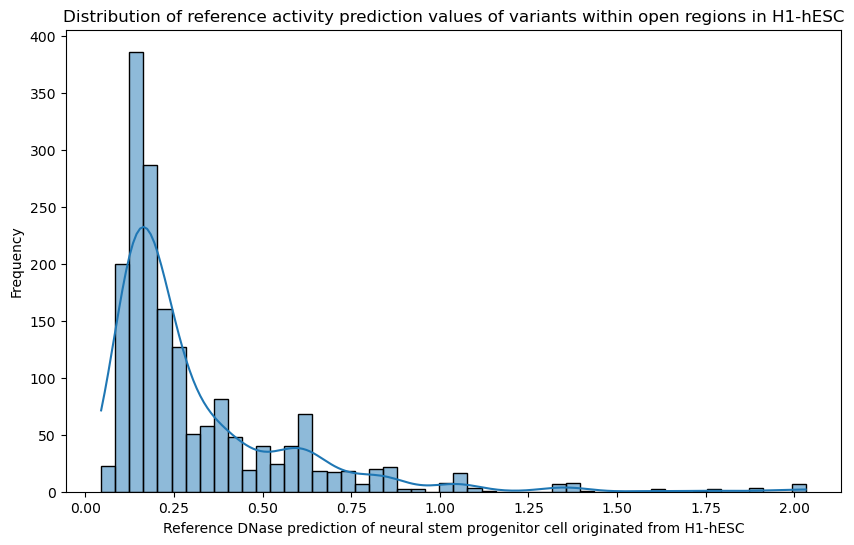

In [162]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the 'Value' column

# Using sns.histplot for a histogram
plt.figure(figsize=(10, 6))
sns.histplot(merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'], bins=50, kde=True)
plt.title('Distribution of reference activity prediction values of variants within open regions in H1-hESC')
plt.xlabel('Reference DNase prediction of neural stem progenitor cell originated from H1-hESC')
plt.ylabel('Frequency')
plt.show()

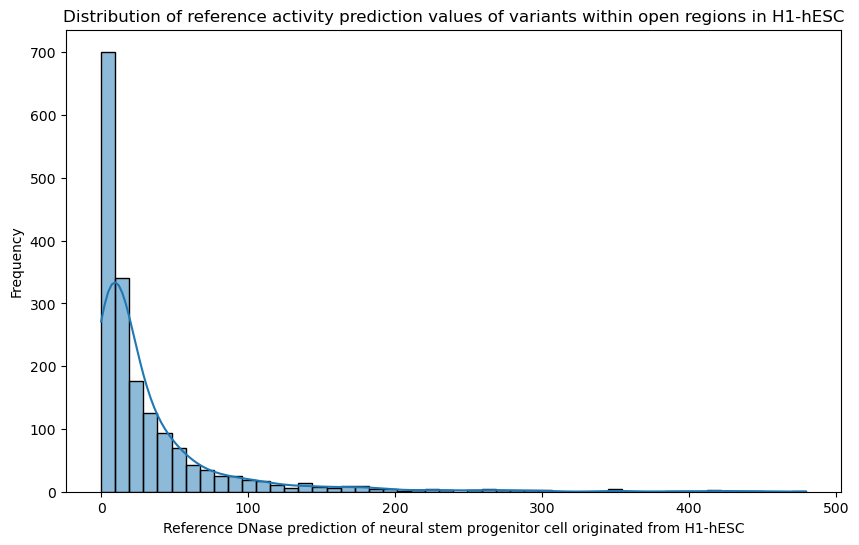

In [166]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the 'Value' column

# Using sns.histplot for a histogram
plt.figure(figsize=(10, 6))
# sns.histplot(merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'], bins=50, kde=True)
# sns.histplot(merged_bcMPRAlm_snakeflow_info_H1_open['variant_DNASE:neural stem progenitor cell originated from H1-hESC'], bins=50, kde=True)
sns.histplot(merged_bcMPRAlm_snakeflow_info_H1_open['variant_DNASE_H1_hESC_abs'], bins=50, kde=True)
plt.title('Distribution of reference activity prediction values of variants within open regions in H1-hESC')
plt.xlabel('Reference DNase prediction of neural stem progenitor cell originated from H1-hESC')
plt.ylabel('Frequency')
plt.show()


/tmp/ipykernel_65674/2609434280.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info_H1_open['REF_H1_DNase_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'], q=num_bins, labels=bin_labels)
/tmp/ipykernel_65674/2609434280.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group = merged_bcMPRAlm_snakeflow_info_H1_open.groupby(['REF_H1_DNase_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_65674/2609434280.py:31: FutureWarning: 

Passi

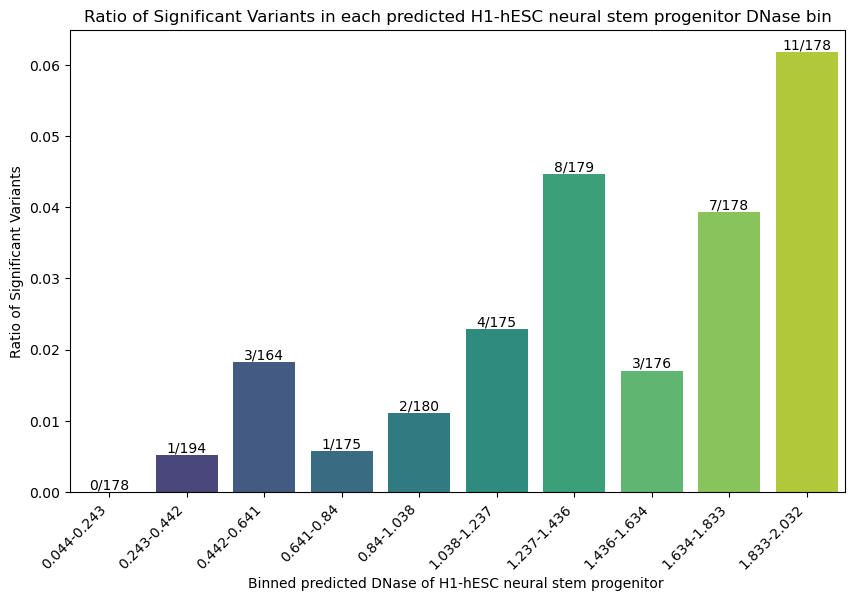

In [141]:
# Calculate the range of REF_mean_log2
min_value = merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'].min()
max_value = merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'].max()
# max_value = 2

# Define the number of bins
num_bins = 10

# Prepare bin edges
bin_edges = np.linspace(min_value, max_value, num_bins + 1)
bin_edges
# Prepare bin labels
bin_labels = [f'{round(bin_edges[i],3)}-{round(bin_edges[i+1], 3)}' for i in range(len(bin_edges) - 1)]
bin_labels
# # Create bins for REF_mean_log2 with specified labels
merged_bcMPRAlm_snakeflow_info_H1_open['REF_H1_DNase_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'], q=num_bins, labels=bin_labels)

# merged_bcMPRAlm_snakeflow_info_H1_open['REF_H1_DNase_bin'] = pd.cut(merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'], bins=bin_edges, labels=bin_labels, right=False)

# Group by the bins and count the number of significant and non-significant variants
bin_group = merged_bcMPRAlm_snakeflow_info_H1_open.groupby(['REF_H1_DNase_bin', 'is_significant']).size().unstack(fill_value=0)

# Calculate the ratio of significant variants in each bin
bin_group['ratio_significant'] = bin_group['yes'] / (bin_group['yes'] + bin_group['no'])

# Reset index to make 'REF_H1_DNase_bin' a regular column
bin_group.reset_index(inplace=True)

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=bin_group, x='REF_H1_DNase_bin', y='ratio_significant', palette='viridis')

# Add labels and title
plt.xlabel('Binned predicted DNase of H1-hESC neural stem progenitor ')
plt.ylabel('Ratio of Significant Variants')
plt.title('Ratio of Significant Variants in each predicted H1-hESC neural stem progenitor DNase bin')
# Rotate x-axis labels by 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


# Annotate the number of observations in each group
for index, row in bin_group.iterrows():
    ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')


# Show the plot
plt.show()

##### Investigate proportion of significant results within the neuro specific regions
- check the annotated gene sets
- check the annotated variant types

In [142]:
merged_bcMPRAlm_snakeflow_info_H1_open['gene_set_list'].value_counts()
# gene_set
# cardiac    627
# neuro      580
# random     319
# cava       300

gene_set_list
[cardiac]           583
[neuro]             541
[random]            319
[cava]              285
[neuro, cardiac]     34
[cardiac, cava]       7
[neuro, cava]         5
[cava, cardiac]       3
Name: count, dtype: int64

In [143]:
merged_bcMPRAlm_snakeflow_info_H1_open['variant_type'].value_counts()


variant_type
singleton     558
ultra-rare    532
common        361
rare          326
Name: count, dtype: int64

In [144]:
significant_within_regions = merged_bcMPRAlm_snakeflow_info_H1_open.loc[merged_bcMPRAlm_snakeflow_info_H1_open['adj.P.Val'] < 0.05]
significant_within_regions['gene_set_list'].value_counts()


gene_set_list
[cardiac]          15
[neuro]            15
[cava]              6
[random]            3
[cardiac, cava]     1
Name: count, dtype: int64

In [145]:
significant_within_regions['variant_type'].value_counts()


variant_type
ultra-rare    17
singleton      9
rare           9
common         5
Name: count, dtype: int64

In [146]:
(significant_within_regions['variant_log2FC'] > 0).sum() #

24

Now only neuro specific

In [147]:
neuro_specific_H1_open = merged_bcMPRAlm_snakeflow_info_H1_open.loc[merged_bcMPRAlm_snakeflow_info_H1_open['gene_set_list'].apply(lambda x: hf.is_element_of(x, 'neuro'))]
neuro_specific_H1_open # 580

neuro_open_gene_set_distri = neuro_specific_H1_open['gene_set_list'].value_counts()
# [neuro]             541
# [neuro, cardiac]     34
# [neuro, cava]         5

neuro_open_variant_type_distri = neuro_specific_H1_open['variant_type'].value_counts()
# variant_type
# common        172
# rare          168
# ultra-rare    125
# singleton     115

neuro_open_significant = neuro_specific_H1_open.loc[neuro_specific_H1_open['adj.P.Val'] < 0.05]
neuro_open_significant # 15
neuro_open_significant_gene_set_distri = neuro_open_significant['variant_type'].value_counts()
# variant_type
# ultra-rare    8
# rare          4
# singleton     2
# common        1

Compare to distribution of significant results not being in these regions

In [152]:
merged_bcMPRAlm_snakeflow_info_H1_open.head()
merged_bcMPRAlm_snakeflow_info_H1_open.loc[merged_bcMPRAlm_snakeflow_info_H1_open['gene_set_list'].apply(lambda x: hf.is_element_of(x, 'neuro'))]

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,REF_DNASE:neural stem progenitor cell originated from H1-hESC,id,variant_DNASE:neural stem progenitor cell originated from H1-hESC,variant_type_list,region_info,region,chrom,start,end,REF_H1_DNase_bin
63,1.090563,0.784401,7.019211,1.454739e-11,8.340654e-09,15.600715,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,Region=LZTR1|ENSG00000099949.22|EH38E3469088_f...,0.000020,3.0,...,0.6344,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,178.161400,[ultra-rare],EH38E3469088,EH38E3469088,chr22,21014704.0,21015053.0,1.833-2.032
72,1.221552,0.705690,6.746849,9.428517e-11,4.739315e-08,13.690928,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,Region=LZTR1|ENSG00000099949.22|EH38E3469088_f...,0.000013,2.0,...,0.6344,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,139.953370,[ultra-rare],EH38E3469088,EH38E3469088,chr22,21014704.0,21015053.0,1.833-2.032
136,0.927651,0.619708,5.386129,1.536207e-07,4.114568e-05,6.993683,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,Region=LZTR1|ENSG00000099949.22|EH38E3469088_f...,0.000013,2.0,...,0.6344,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,8.950502,[ultra-rare],EH38E3469088,EH38E3469088,chr22,21014704.0,21015053.0,1.833-2.032
181,0.716936,0.649383,4.839820,1.934380e-06,3.887623e-04,4.704085,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,Region=LZTR1|ENSG00000099949.22|EH38E3469088_f...,0.000026,4.0,...,0.6344,cardiac_neuro_cava_random:LZTR1|ENSG0000009994...,66.185080,[ultra-rare],EH38E3469088,EH38E3469088,chr22,21014704.0,21015053.0,1.833-2.032
182,0.567501,1.942942,4.824536,2.003155e-06,3.994770e-04,4.650192,cardiac_neuro_cava_random:MTOR|ENSG00000198793...,Region=MTOR|ENSG00000198793.14|EH38E1318759_re...,0.017086,2601.0,...,0.1852,cardiac_neuro_cava_random:MTOR|ENSG00000198793...,-6.619799,[rare],EH38E1318759,EH38E1318759,chr1,11287066.0,11287398.0,0.84-1.038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35251,-0.019996,-0.049709,-0.244376,8.070036e-01,9.707694e-01,-6.699912,cardiac_neuro_cava_random:LRRC4C|ENSG000001489...,Region=LRRC4C|ENSG00000148948.8|EH38E1534702_r...,0.020798,3164.0,...,0.1974,cardiac_neuro_cava_random:LRRC4C|ENSG000001489...,7.641679,[rare],EH38E1534702,EH38E1534702,chr11,41308347.0,41308693.0,0.84-1.038
35621,0.028806,-0.013551,0.373009,7.092317e-01,9.528381e-01,-6.747032,cardiac_neuro_cava_random:NBEA|ENSG00000172915...,Region=NBEA|ENSG00000172915.20|EH38E1667522_fw...,0.010438,1588.0,...,0.0917,cardiac_neuro_cava_random:NBEA|ENSG00000172915...,5.149928,[rare],EH38E1667522,EH38E1667522,chr13,35477057.0,35477265.0,0.044-0.243
35753,0.001847,-0.111496,0.023151,9.815358e-01,9.959129e-01,-6.765079,cardiac_neuro_cava_random:RERE|ENSG00000142599...,Region=RERE|ENSG00000142599.20|EH38E1316082_re...,0.024226,3684.0,...,0.1486,cardiac_neuro_cava_random:RERE|ENSG00000142599...,0.368723,[rare],EH38E1316082,EH38E1316082,chr1,8419962.0,8420218.0,0.442-0.641
35795,0.009779,-0.028999,0.129976,8.966167e-01,9.864391e-01,-6.772484,cardiac_neuro_cava_random:KANSL1|ENSG000001200...,Region=KANSL1|ENSG00000120071.15|EH38E3227102_...,0.115913,17415.0,...,0.1237,cardiac_neuro_cava_random:KANSL1|ENSG000001200...,4.649211,[common],EH38E3227102,EH38E3227102,chr17,46146094.0,46146381.0,0.243-0.442


/tmp/ipykernel_65674/2609434280.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info_H1_open['REF_H1_DNase_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'], q=num_bins, labels=bin_labels)
/tmp/ipykernel_65674/2609434280.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group = merged_bcMPRAlm_snakeflow_info_H1_open.groupby(['REF_H1_DNase_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_65674/2609434280.py:31: FutureWarning: 

Passi

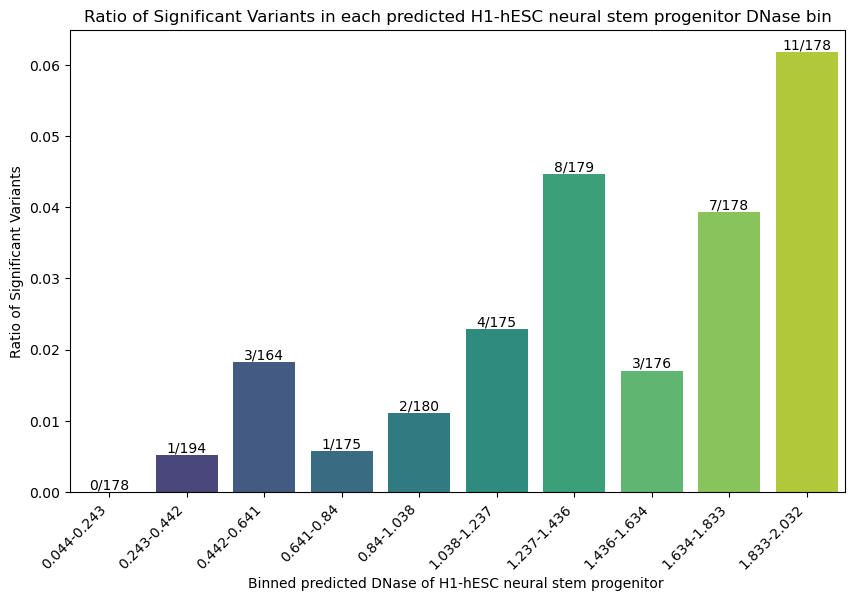

In [153]:
# Calculate the range of REF_mean_log2
min_value = merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'].min()
max_value = merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'].max()
# max_value = 2

# Define the number of bins
num_bins = 10

# Prepare bin edges
bin_edges = np.linspace(min_value, max_value, num_bins + 1)
bin_edges
# Prepare bin labels
bin_labels = [f'{round(bin_edges[i],3)}-{round(bin_edges[i+1], 3)}' for i in range(len(bin_edges) - 1)]
bin_labels
# # Create bins for REF_mean_log2 with specified labels
merged_bcMPRAlm_snakeflow_info_H1_open['REF_H1_DNase_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'], q=num_bins, labels=bin_labels)

# merged_bcMPRAlm_snakeflow_info_H1_open['REF_H1_DNase_bin'] = pd.cut(merged_bcMPRAlm_snakeflow_info_H1_open['REF_DNASE:neural stem progenitor cell originated from H1-hESC'], bins=bin_edges, labels=bin_labels, right=False)

# Group by the bins and count the number of significant and non-significant variants
bin_group = merged_bcMPRAlm_snakeflow_info_H1_open.groupby(['REF_H1_DNase_bin', 'is_significant']).size().unstack(fill_value=0)

# Calculate the ratio of significant variants in each bin
bin_group['ratio_significant'] = bin_group['yes'] / (bin_group['yes'] + bin_group['no'])

# Reset index to make 'REF_H1_DNase_bin' a regular column
bin_group.reset_index(inplace=True)

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=bin_group, x='REF_H1_DNase_bin', y='ratio_significant', palette='viridis')

# Add labels and title
plt.xlabel('Binned predicted DNase of H1-hESC neural stem progenitor ')
plt.ylabel('Ratio of Significant Variants')
plt.title('Ratio of Significant Variants in each predicted H1-hESC neural stem progenitor DNase bin')
# Rotate x-axis labels by 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


# Annotate the number of observations in each group
for index, row in bin_group.iterrows():
    ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')


# Show the plot
plt.show()

#### Load random class table and merge with bcMPRAlm results

In [154]:
enformer_random_variants_df = pd.read_csv(config['files']['creating']['enformer_random_variants'], sep="\t")
enformer_random_variants_df
enformer_random_variants_df['chr_pos_ref_alt'] = enformer_random_variants_df['ID'].apply(hf.get_chrom_pos_ref_alt_pattern)
print(f"Number of random classes: {enformer_random_variants_df.shape[0]} {enformer_random_variants_df['chr_pos_ref_alt'].nunique()} (Same? => unique chr pos ref alt)")

# read the variant table
bcMPRAlm_df = pd.read_csv(config['files']['creating']['toptable_bcMPRAlm_resequencing'], sep="\t")
bcMPRAlm_df
# only tested:
tested_bcMPRAlm_df = bcMPRAlm_df.loc[bcMPRAlm_df['variant_id'].str.startswith('cardiac_neuro_cava_random')]
tested_bcMPRAlm_df
tested_bcMPRAlm_df['chr_pos_ref_alt'] = tested_bcMPRAlm_df['variant_id'].apply(hf.get_chrom_pos_ref_alt_pattern)

print(f"Number of bcMPRAlm results: {tested_bcMPRAlm_df.shape[0]} {tested_bcMPRAlm_df['chr_pos_ref_alt'].nunique()} (Same? => unique chr pos ref alt)")



mpralm_results_random = enformer_random_variants_df.merge(tested_bcMPRAlm_df, on='chr_pos_ref_alt', how='left')

merged_mpralm_results_random = mpralm_results_random.loc[~mpralm_results_random['adj.P.Val'].isna()]
not_merged_mpralm_results_random = mpralm_results_random.loc[mpralm_results_random['adj.P.Val'].isna()]
print(f'Number of merged_mpralm for random', merged_mpralm_results_random.shape[0]) # 27.05: 2857

Number of random classes: 5456 5456 (Same? => unique chr pos ref alt)
Number of bcMPRAlm results: 36168 36168 (Same? => unique chr pos ref alt)
Number of merged_mpralm for random 2857


/tmp/ipykernel_65674/3905649886.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcMPRAlm_df['chr_pos_ref_alt'] = tested_bcMPRAlm_df['variant_id'].apply(hf.get_chrom_pos_ref_alt_pattern)


##### Find how many elements are there open in H1

In [155]:
merged_mpralm_results_random['region_info'] = merged_mpralm_results_random['variant_id'].apply(get_region_info)

/tmp/ipykernel_65674/2489375517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_mpralm_results_random['region_info'] = merged_mpralm_results_random['variant_id'].apply(get_region_info)


In [156]:
tmp_merged_mpralm_results_random_H1 = merged_mpralm_results_random.merge(screen_h1_DNase_H1_neuro_bed[['region', 'chrom', 'start', 'end']], left_on='region_info', right_on='region', how='left')
merged_mpralm_results_random_H1_open = tmp_merged_mpralm_results_random_H1.loc[~tmp_merged_mpralm_results_random_H1['chrom'].isna()]

In [157]:
print(f'Number of open elements in merged_bcMPRAlm_snakeflow_info {merged_mpralm_results_random_H1_open.shape[0]}, ratio: {merged_mpralm_results_random_H1_open.shape[0]/merged_mpralm_results_random.shape[0]}')

Number of open elements in merged_bcMPRAlm_snakeflow_info 143, ratio: 0.05005250262513126


In [158]:
merged_mpralm_results_random_H1_open

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,...,t,P.Value,adj.P.Val,B,variant_id,region_info,region,chrom,start,end
30,chr1,21238643,ECE1|ENSG00000117298.16|EH38E2792679|1-2123864...,A,G,1,PASS,AF=1.32018e-05;AC=2,1-21238643-A-G,99.946140,...,1.146360,0.252714,0.777416,-5.291315,cardiac_neuro_cava_random:ECE1|ENSG00000117298...,EH38E2792679,EH38E2792679,chr1,21238469.0,21238816.0
77,chr15,96362258,NR2F2|ENSG00000185551.15|EH38E3157183|15-96362...,G,T,1,PASS,AF=4.61066e-05;AC=7,15-96362258-G-T,53.873955,...,1.115532,0.265104,0.786006,-5.912038,cardiac_neuro_cava_random:NR2F2|ENSG0000018555...,EH38E3157183,EH38E3157183,chr15,96362219.0,96362409.0
78,chr10,21314968,NEBL|ENSG00000078114.19|EH38E2890005|10-213149...,C,T,1,PASS,AF=1.31456e-05;AC=2,10-21314968-C-T,52.433865,...,-1.343787,0.180543,0.720939,-4.882037,cardiac_neuro_cava_random:NEBL|ENSG00000078114...,EH38E2890005,EH38E2890005,chr10,21314812.0,21315004.0
86,chr9,136588747,NOTCH1|ENSG00000148400.13|EH38E3919979|9-13658...,C,T,1,PASS,AF=1.31415e-05;AC=2,9-136588747-C-T,48.994595,...,0.261755,0.793720,0.968924,-5.928799,cardiac_neuro_cava_random:NOTCH1|ENSG000001484...,EH38E3919979,EH38E3919979,chr9,136588542.0,136588854.0
87,chr9,91857944,ROR2|ENSG00000169071.15|EH38E3893219|9-9185794...,T,G,1,PASS,AF=1.31472e-05;AC=2,9-91857944-T-G,48.853040,...,0.171228,0.864119,0.980583,-6.253979,cardiac_neuro_cava_random:ROR2|ENSG00000169071...,EH38E3893219,EH38E3893219,chr9,91857878.0,91858077.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,chr1,94866290,CNN3|ENSG00000117519.16|EH38E1369410|1-9486629...,G,A,1,PASS,AF=6.57358e-06;AC=1,1-94866290-G-A,22.583511,...,-1.149717,0.250882,0.775948,-5.744912,cardiac_neuro_cava_random:CNN3|ENSG00000117519...,EH38E1369410,EH38E1369410,chr1,94866243.0,94866393.0
2722,chr2,74513884,MOGS|ENSG00000115275.15|EH38E3353146|2-7451388...,G,T,1,PASS,AF=6.57454e-06;AC=1,2-74513884-G-T,21.022625,...,-1.237785,0.216722,0.753281,-5.303204,cardiac_neuro_cava_random:MOGS|ENSG00000115275...,EH38E3353146,EH38E3353146,chr2,74513691.0,74513887.0
2727,chr1,94954849,CNN3|ENSG00000117519.16|EH38E1369510|1-9495484...,C,T,1,PASS,AF=6.57367e-06;AC=1,1-94954849-C-T,19.859678,...,0.431223,0.666637,0.942085,-5.953109,cardiac_neuro_cava_random:CNN3|ENSG00000117519...,EH38E1369510,EH38E1369510,chr1,94954639.0,94954890.0
2729,chr6,26284087,H1-3|ENSG00000124575.7|EH38E3697739|6-26284087...,A,T,1,PASS,AF=6.57635e-06;AC=1,6-26284087-A-T,19.345520,...,0.983491,0.326083,0.823772,-5.714215,cardiac_neuro_cava_random:H1-3|ENSG00000124575...,EH38E3697739,EH38E3697739,chr6,26283860.0,26284164.0


In [159]:
merged_mpralm_results_random_H1_open.loc[merged_mpralm_results_random_H1_open['adj.P.Val'] < 0.05].shape[0]

0